In [23]:
# %matplotlib macosx
import copy
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from optim import SSBFGS, SSBroyden

In [24]:
class Net(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, x, y):
        X = torch.cat([x, y], dim=1)
        return self.net(X)

class HardCodeNet(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, x, y):
        X = torch.cat([x, y], dim=1)
        N_out = self.net(X)
        u_pred = (1.0 - x**2) * (1.0 - y**2) * N_out
        return u_pred

Solve the 2D Helmholtz equation in a square domain $\Omega = [-1, 1] \times [-1, 1]$

$$\begin{cases}
    \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} + u - (1 - 17\pi^2) \sin(\pi x) \sin(4\pi y) = 0 & \ \text{ in } \Omega \\
    u(x, y) = 0 & \ \text{ on } \partial \Omega
\end{cases}$$
With exact solution $u(x, y) = \sin(\pi x) \sin(4\pi y)$.

In [25]:
torch.manual_seed(42)
np.random.seed(42)

In [26]:
# --- Collocation points ---
N_f = 10000
x_f = (torch.rand(N_f, 1) * 2 - 1).requires_grad_(True)
y_f = (torch.rand(N_f, 1) * 2 - 1).requires_grad_(True)

pi = torch.pi
f = ((1.0 - 17.0*pi**2)*torch.sin(pi*x_f)*torch.sin(4*pi*y_f)).detach()

# --- Boundary points ---
N_b = 800
# y = -1, y = 1, x = -1, x = 1
x_b = torch.cat([torch.rand(N_b//4, 1) * 2 - 1, torch.rand(N_b//4, 1) * 2 - 1, -torch.ones(N_b//4, 1), torch.ones(N_b//4, 1)], dim=0)
y_b = torch.cat([-torch.ones(N_b//4, 1), torch.ones(N_b//4, 1), torch.rand(N_b//4, 1) * 2 - 1, torch.rand(N_b//4, 1) * 2 - 1], dim=0)

# --- Exact solution at boundary points ---
u_exact_train = (torch.sin(pi*x_f) * torch.sin(4*pi*y_f)).detach()
l1_error = {}
l2_error = {}
l2_relative_error = {}
mse = {}
l_inf_error = {}

In [27]:
# --- Initialize the network ---
layers = [2, 50, 50, 50, 50, 1]
net = Net(layers)
optimizer = optim.Adam(net.parameters(), lr=1e-3)

l1_error["Standard"] = []
l2_error["Standard"] = []
l2_relative_error["Standard"] = []
mse["Standard"] = []
l_inf_error["Standard"] = []

# --- Training loop ---
start = time.time()
for epoch in range(5000):
    optimizer.zero_grad()

    # Wipe the input gradients alongside the optimizer!
    if x_f.grad is not None: x_f.grad.zero_()
    if y_f.grad is not None: y_f.grad.zero_()

    # --- Compute the PDE residual ---
    u_pred = net(x_f, y_f)
    u_x = torch.autograd.grad(u_pred, x_f, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_y = torch.autograd.grad(u_pred, y_f, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]

    residual = u_xx + u_yy + u_pred - f
    loss_pde = torch.mean(residual**2)

    # --- Compute the boundary loss ---
    u_b_pred = net(x_b, y_b)
    loss_bc = torch.mean(u_b_pred**2)

    # --- Total loss ---
    loss = loss_pde + loss_bc

    # --- Backpropagation ---
    loss.backward()
    optimizer.step()

    l1_error["Standard"].append(torch.mean(torch.abs(u_pred - u_exact_train)).item())
    l2_error["Standard"].append(torch.sqrt(torch.mean((u_pred - u_exact_train)**2)).item())
    l2_relative_error["Standard"].append(torch.sqrt(torch.mean((u_pred - u_exact_train)**2)).item() / torch.sqrt(torch.mean(u_exact_train**2)).item())
    mse["Standard"].append(torch.mean((u_pred - u_exact_train)**2).item())
    l_inf_error["Standard"].append(torch.max(torch.abs(u_pred - u_exact_train)).item())

    if epoch % 500 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}, PDE Loss: {loss_pde.item():.6f}, Boundary Loss: {loss_bc.item():.6f}')

print(f'Training completed in {time.time() - start:.2f} seconds')

Epoch 0, Loss: 6934.944336, PDE Loss: 6934.916016, Boundary Loss: 0.028253
Epoch 500, Loss: 293.589447, PDE Loss: 270.064301, Boundary Loss: 23.525156
Epoch 1000, Loss: 42.328339, PDE Loss: 23.633444, Boundary Loss: 18.694895
Epoch 1500, Loss: 12.340434, PDE Loss: 4.713064, Boundary Loss: 7.627370
Epoch 2000, Loss: 4.703663, PDE Loss: 1.904033, Boundary Loss: 2.799630
Epoch 2500, Loss: 2.926291, PDE Loss: 1.198758, Boundary Loss: 1.727533
Epoch 3000, Loss: 1.965379, PDE Loss: 0.837912, Boundary Loss: 1.127468
Epoch 3500, Loss: 1.471572, PDE Loss: 0.670707, Boundary Loss: 0.800865
Epoch 4000, Loss: 1.082244, PDE Loss: 0.494735, Boundary Loss: 0.587509
Epoch 4500, Loss: 0.915637, PDE Loss: 0.470635, Boundary Loss: 0.445002
Training completed in 347.35 seconds


In [28]:
def compute_loss(net):
    # Wipe the input gradients inside the closure!
    if x_f.grad is not None: x_f.grad.zero_()
    if y_f.grad is not None: y_f.grad.zero_()

    # PDE residual
    u_f = net(x_f, y_f)
    u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
    u_y = torch.autograd.grad(u_f.sum(), y_f ,create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, torch.ones_like(u_y), create_graph=True)[0]

    residual = u_xx + u_yy + u_f - f
    loss_pde = torch.mean(residual**2)

    return loss_pde

def record_metrics(net, name):
    # Disable gradients just for metric calculation to save memory/time
    with torch.no_grad():
        u_f = net(x_f, y_f)
        diff = u_f - u_exact_train

        l1_error[name].append(torch.mean(torch.abs(diff)).item())
        l2_error[name].append(torch.sqrt(torch.mean(diff ** 2)).item())
        l2_relative_error[name].append((torch.norm(diff) / torch.norm(u_exact_train)).item())
        mse[name].append(torch.mean(diff ** 2).item())
        l_inf_error[name].append(torch.max(torch.abs(diff)).item())

        plateau_mse = False
        if len(mse[name]) > 100:
            window = mse[name][-100:]
            rel_spread = (max(window) - min(window)) / (min(window) + 1e-12)
            plateau_mse = rel_spread < 1e-4

        return plateau_mse

In [29]:
model = HardCodeNet(layers)

l1_error["HC Boundaries"] = []
l2_error["HC Boundaries"] = []
l2_relative_error["HC Boundaries"] = []
mse["HC Boundaries"] = []
l_inf_error["HC Boundaries"] = []

# --- Stage 1: Adam Optimizer (Initialization) ---
print("Stage 1: Pre-training with Adam...")
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)

start = time.time()
for epoch in range(2000): # Adam iterations
    optimizer_adam.zero_grad()
    loss = compute_loss(model)
    loss.backward()
    optimizer_adam.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(model, 'HC Boundaries')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6e}")

adam_time = time.time() - start

Stage 1: Pre-training with Adam...
Epoch 0, Loss: 6.934789e+03
Epoch 500, Loss: 1.861012e+03
Epoch 1000, Loss: 1.272015e+02
Epoch 1500, Loss: 3.049308e+01


In [30]:
model_std_lbfgs = copy.deepcopy(model) # Experiment 2
l1_error["std"] = l1_error["HC Boundaries"][:]
l2_error["std"] = l2_error["HC Boundaries"][:]
l2_relative_error["std"] = l2_relative_error["HC Boundaries"][:]
mse["std"] = mse["HC Boundaries"][:]
l_inf_error["std"] = l_inf_error["HC Boundaries"][:]

model_sqrt_lbfgs = copy.deepcopy(model) # Experiment 3
l1_error["sqrt"] = l1_error["HC Boundaries"][:]
l2_error["sqrt"] = l2_error["HC Boundaries"][:]
l2_relative_error["sqrt"] = l2_relative_error["HC Boundaries"][:]
mse["sqrt"] = mse["HC Boundaries"][:]
l_inf_error["sqrt"] = l_inf_error["HC Boundaries"][:]

model_log_lbfgs = copy.deepcopy(model) # Experiment 4
l1_error["log"] = l1_error["HC Boundaries"][:]
l2_error["log"] = l2_error["HC Boundaries"][:]
l2_relative_error["log"] = l2_relative_error["HC Boundaries"][:]
mse["log"] = mse["HC Boundaries"][:]
l_inf_error["log"] = l_inf_error["HC Boundaries"][:]

model_ssbfgs = copy.deepcopy(model) # Experiment 5
l1_error["ssbfgs"] = l1_error["HC Boundaries"][:]
l2_error["ssbfgs"] = l2_error["HC Boundaries"][:]
l2_relative_error["ssbfgs"] = l2_relative_error["HC Boundaries"][:]
mse["ssbfgs"] = mse["HC Boundaries"][:]
l_inf_error["ssbfgs"] = l_inf_error["HC Boundaries"][:]

model_ssbroyden = copy.deepcopy(model) # Experiment 6
l1_error["ssbroyden"] = l1_error["HC Boundaries"][:]
l2_error["ssbroyden"] = l2_error["HC Boundaries"][:]
l2_relative_error["ssbroyden"] = l2_relative_error["HC Boundaries"][:]
mse["ssbroyden"] = mse["HC Boundaries"][:]
l_inf_error["ssbroyden"] = l_inf_error["HC Boundaries"][:]

In [31]:
# --- EXPERIMENT 1: Continue with Adam (No LBFGS) ---
print("Exp 1: Continuing Adam...")
start = time.time()
for epoch in range(3000):
    optimizer_adam.zero_grad()
    loss = compute_loss(model)
    loss.backward()
    optimizer_adam.step()

    # Record metrics exactly once per epoch
    plateau = record_metrics(model, 'HC Boundaries')
    if plateau:
        break

    if epoch % 500 == 0:
        print(f"Epoch {epoch},  Loss: {loss.item():.6e}")

print(f"Total time Adam: {adam_time + time.time() - start:.2f} seconds")

Exp 1: Continuing Adam...
Epoch 0,  Loss: 3.203351e+00
Epoch 500,  Loss: 1.549141e+00
Epoch 1000,  Loss: 1.094378e+00
Epoch 1500,  Loss: 8.786119e-01
Epoch 2000,  Loss: 7.222539e-01
Epoch 2500,  Loss: 6.735343e-01
Total time Adam: 410.89 seconds


In [32]:
# --- EXPERIMENT 2: Standard LBFGS (Minimize MSE) ---
print("Exp 2: Standard LBFGS (MSE)...")
opt_std = optim.LBFGS(
    model_std_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

lbfgs_epochs = 3000

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_std():
        opt_std.zero_grad()
        loss = compute_loss(model_std_lbfgs) # Standard Loss
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_std.step(closure_std)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_std_lbfgs, 'std')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_std().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {loss_val.item():.6e}")

lbfgs_time = adam_time + time.time() - start
print(f"Total time (Adam + LBFGS): {lbfgs_time:.2f} seconds")

Exp 2: Standard LBFGS (MSE)...
L-BFGS Epoch 0, Loss: 3.203351e+00
L-BFGS Epoch 500, Loss: 1.868190e-01
L-BFGS Epoch 1000, Loss: 6.620200e-02
L-BFGS Epoch 1500, Loss: 2.999778e-02
L-BFGS Epoch 2000, Loss: 1.573545e-02
L-BFGS Epoch 2500, Loss: 9.429983e-03
Total time (Adam + LBFGS): 656.01 seconds


In [33]:
# --- EXPERIMENT 3: Modified LBFGS (Minimize Sqrt(MSE)) ---
print("Exp 3: Modified LBFGS (J_1/2)...")
opt_sqrt = optim.LBFGS(
    model_sqrt_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_sqrt():
        opt_sqrt.zero_grad()
        loss_mse = compute_loss(model_sqrt_lbfgs)
        loss_sqrt = torch.sqrt(loss_mse)
        loss_sqrt.backward()
        return loss_sqrt

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_sqrt.step(closure_sqrt)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_sqrt_lbfgs, 'sqrt')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_sqrt().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {math.pow(loss_val.item(), 2):.6e}")

sqrt_time = adam_time + time.time() - start
print(f"Total time (Adam + sqrt LBFGS): {sqrt_time:.2f} seconds")

Exp 3: Modified LBFGS (J_1/2)...
L-BFGS Epoch 0, Loss: 3.203351e+00
L-BFGS Epoch 500, Loss: 1.881257e-01
L-BFGS Epoch 1000, Loss: 6.515946e-02
L-BFGS Epoch 1500, Loss: 2.906385e-02
L-BFGS Epoch 2000, Loss: 1.555429e-02
L-BFGS Epoch 2500, Loss: 9.151232e-03
Total time (Adam + sqrt LBFGS): 656.57 seconds


In [34]:
# --- EXPERIMENT 4: Modified LBFGS (Minimize log(MSE)) ---
print("Exp 4: Modified LBFGS (log(J))...")
opt_log = optim.LBFGS(
    model_log_lbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_log():
        opt_log.zero_grad()
        loss_mse = compute_loss(model_log_lbfgs)
        loss_log = torch.log(loss_mse)
        loss_log.backward()
        return loss_log

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_log.step(closure_log)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_log_lbfgs, 'log')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_log().item()
        print(f"L-BFGS Epoch {epoch}, Loss: {math.exp(loss_val.item()):.6e}")

log_time = adam_time + time.time() - start
print(f"Total time (Adam + log LBFGS): {log_time:.2f} seconds")

Exp 4: Modified LBFGS (log(J))...
L-BFGS Epoch 0, Loss: 3.203351e+00
L-BFGS Epoch 500, Loss: 1.863760e-01
L-BFGS Epoch 1000, Loss: 6.610923e-02
L-BFGS Epoch 1500, Loss: 3.030970e-02
L-BFGS Epoch 2000, Loss: 1.624168e-02
L-BFGS Epoch 2500, Loss: 9.768964e-03
Total time (Adam + log LBFGS): 661.83 seconds


In [35]:
# --- EXPERIMENT 5: Modified BFGS (SSBFGS) ---
print("Exp 5: SSBFGS...")
opt_ssbfgs = SSBFGS(
    model_ssbfgs.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_ssbfgs():
        opt_ssbfgs.zero_grad()
        loss = compute_loss(model_ssbfgs)
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_ssbfgs.step(closure_ssbfgs)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_ssbfgs, 'ssbfgs')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_ssbfgs().item()
        print(f"SSBFGS Epoch {epoch}, Loss: {loss_val.item():.6e}")

ssbfgs_time = adam_time + time.time() - start
print(f"Total time (Adam + SSBFGS): {ssbfgs_time:.2f} seconds")

Exp 5: SSBFGS...
SSBFGS Epoch 0, Loss: 3.200023e+00
SSBFGS Epoch 500, Loss: 8.887444e-04
SSBFGS Epoch 1000, Loss: 1.872478e-05
SSBFGS Epoch 1500, Loss: 3.408086e-06
SSBFGS Epoch 2000, Loss: 1.119781e-06
Total time (Adam + SSBFGS): 2243.00 seconds


In [36]:
# --- EXPERIMENT 6: Modified Broyden (SSBroyden) ---
print("Exp 6: SSBroyden...")
opt_ssbroyden = SSBroyden(
    model_ssbroyden.parameters(),
    lr=1.0,
    max_iter=1,
    max_eval=20,
    history_size=100,  # Large history ~ full BFGS
    tolerance_grad=1e-11,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe"
)

start = time.time()
for epoch in range(lbfgs_epochs):
    def closure_ssbroyden():
        opt_ssbroyden.zero_grad()
        loss = compute_loss(model_ssbroyden)
        loss.backward()
        return loss

    # Take ONE step (the line search happens silently inside here)
    loss_val = opt_ssbroyden.step(closure_ssbroyden)

    # Record metrics exactly once per successful step
    plateau = record_metrics(model_ssbroyden, 'ssbroyden')
    if plateau:
        break

    if epoch % 500 == 0:
        # current_loss = closure_ssbroyden().item()
        print(f"SSBroyden Epoch {epoch}, Loss: {loss_val.item():.6e}")

ssbroyden_time = adam_time + time.time() - start
print(f"Total time (Adam + SSBroyden): {ssbroyden_time:.2f} seconds")

Exp 6: SSBroyden...
SSBroyden Epoch 0, Loss: 3.200023e+00
SSBroyden Epoch 500, Loss: 7.988386e-04
SSBroyden Epoch 1000, Loss: 1.917822e-05
SSBroyden Epoch 1500, Loss: 2.739357e-06
SSBroyden Epoch 2000, Loss: 8.103888e-07
SSBroyden Epoch 2500, Loss: 3.998298e-07
Total time (Adam + SSBroyden): 3362.67 seconds


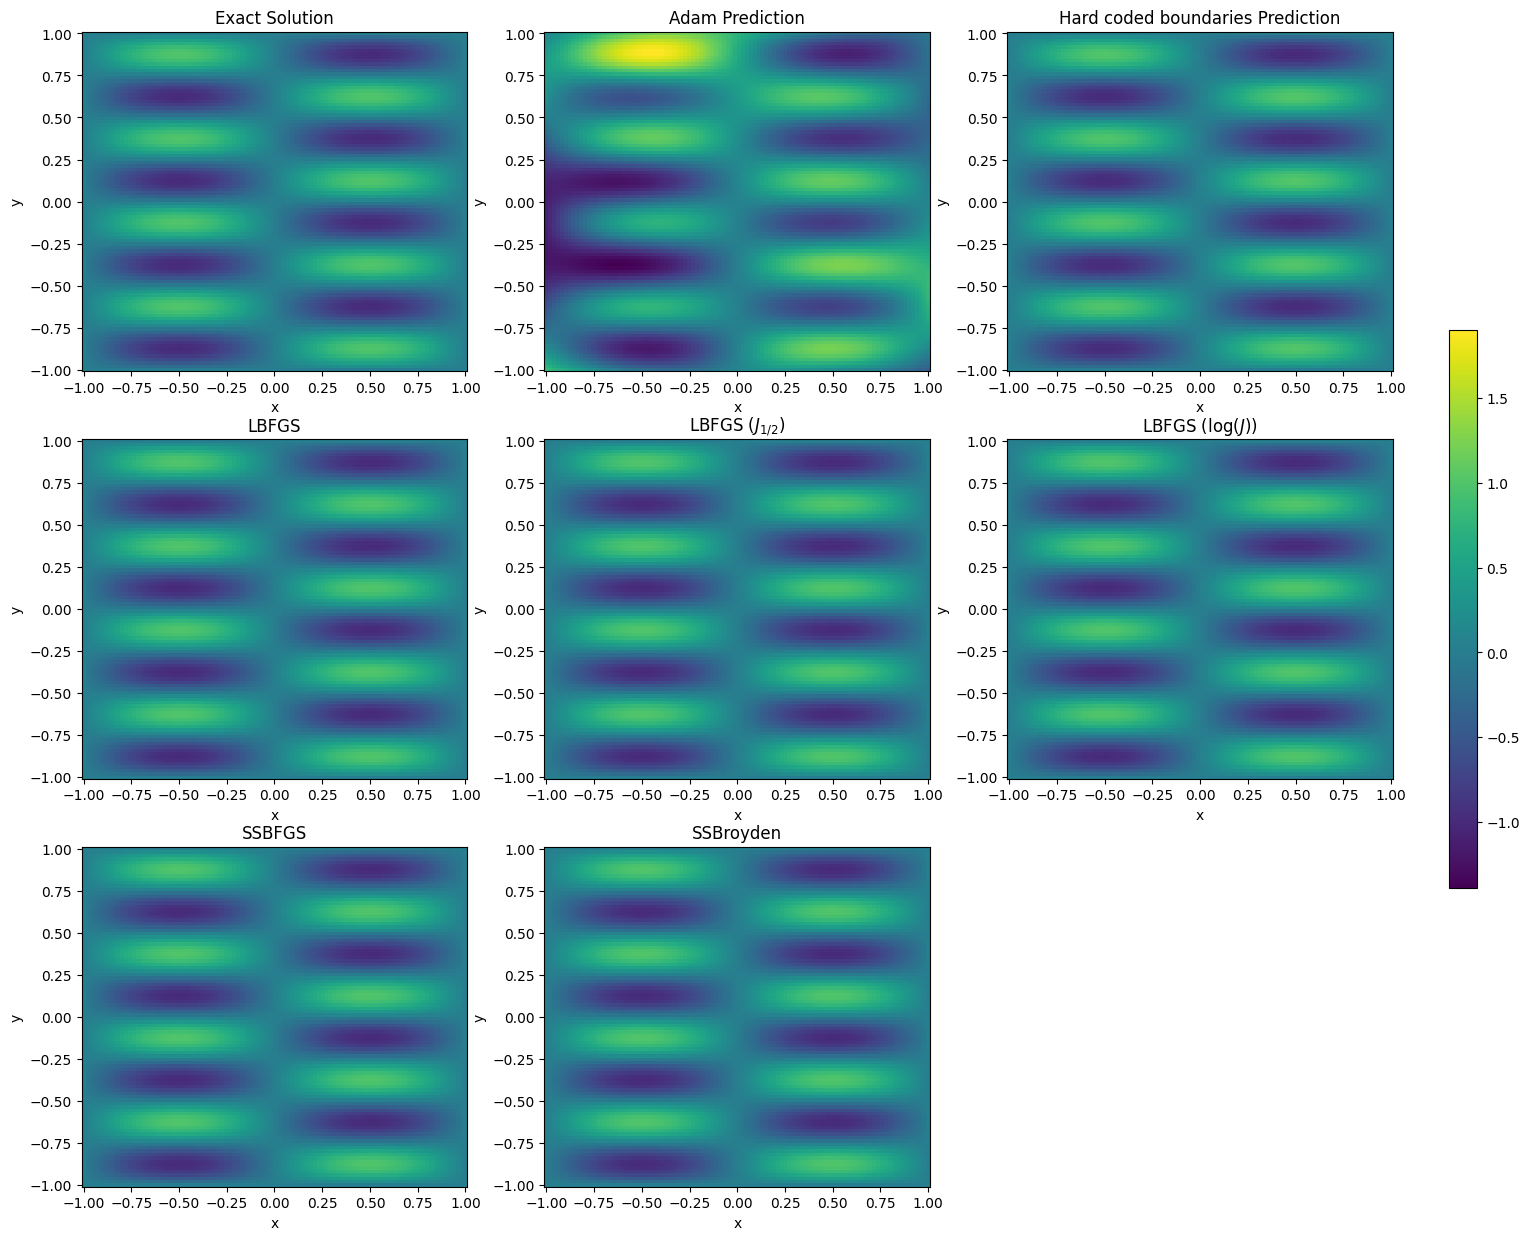

In [37]:
# --- Evaluation ---
x = torch.linspace(-1, 1, 100).reshape(-1, 1)
y = torch.linspace(-1, 1, 100).reshape(-1, 1)
X, Y = torch.meshgrid(x.squeeze(), y.squeeze(), indexing='ij')
X_flat = X.reshape(-1, 1)
Y_flat = Y.reshape(-1, 1)

with torch.no_grad():
    u_pred = net(X_flat, Y_flat).reshape(100,100)
    u_pred_hc = model(X_flat, Y_flat).reshape(100,100)
    u_pred_std = model_std_lbfgs(X_flat, Y_flat).reshape(100, 100)
    u_pred_sqrt = model_sqrt_lbfgs(X_flat, Y_flat).reshape(100, 100)
    u_pred_log = model_log_lbfgs(X_flat, Y_flat).reshape(100, 100)
    u_pred_ssbfgs = model_ssbfgs(X_flat, Y_flat).reshape(100, 100)
    u_pred_ssbroyden = model_ssbroyden(X_flat, Y_flat).reshape(100, 100)
    u_exact_vis = torch.sin(math.pi * X) * torch.sin(4 * math.pi * Y)



all_data = [u_exact_vis, u_pred, u_pred_hc, u_pred_std, u_pred_sqrt, u_pred_log, u_pred_ssbfgs, u_pred_ssbroyden]
vmin = min(d.min() for d in all_data)
vmax = max(d.max() for d in all_data)

fig = plt.figure(figsize=(18,15))

# Exact solution
plt.subplot(3,3,1)
im = plt.pcolormesh(X, Y, u_exact_vis, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Exact Solution')
plt.xlabel('x')
plt.ylabel('y')

# PINN prediction
plt.subplot(3,3,2)
plt.pcolormesh(X, Y, u_pred, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Adam Prediction')
plt.xlabel('x')
plt.ylabel('y')

# Hard coded boundaries prediction
plt.subplot(3,3,3)
plt.pcolormesh(X, Y, u_pred_hc, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('Hard coded boundaries Prediction')
plt.xlabel('x')
plt.ylabel('y')

# Standard LBFGS prediction
plt.subplot(3,3,4)
plt.pcolormesh(X, Y, u_pred_std, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title('LBFGS')
plt.xlabel('x')
plt.ylabel('y')

# Sqrt LBFGS prediction
plt.subplot(3,3,5)
plt.pcolormesh(X, Y, u_pred_sqrt, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($J_{1/2}$)')
plt.xlabel('x')
plt.ylabel('y')

# Log LBFGS prediction
plt.subplot(3,3,6)
plt.pcolormesh(X, Y, u_pred_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'LBFGS ($\log(J)$)')
plt.xlabel('x')
plt.ylabel('y')

# Sqrt SSBFGS prediction
plt.subplot(3,3,7)
plt.pcolormesh(X, Y, u_pred_ssbfgs, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'SSBFGS')
plt.xlabel('x')
plt.ylabel('y')

# Log SSBroyden prediction
plt.subplot(3,3,8)
plt.pcolormesh(X, Y, u_pred_ssbroyden, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
plt.title(r'SSBroyden')
plt.xlabel('x')
plt.ylabel('y')

fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

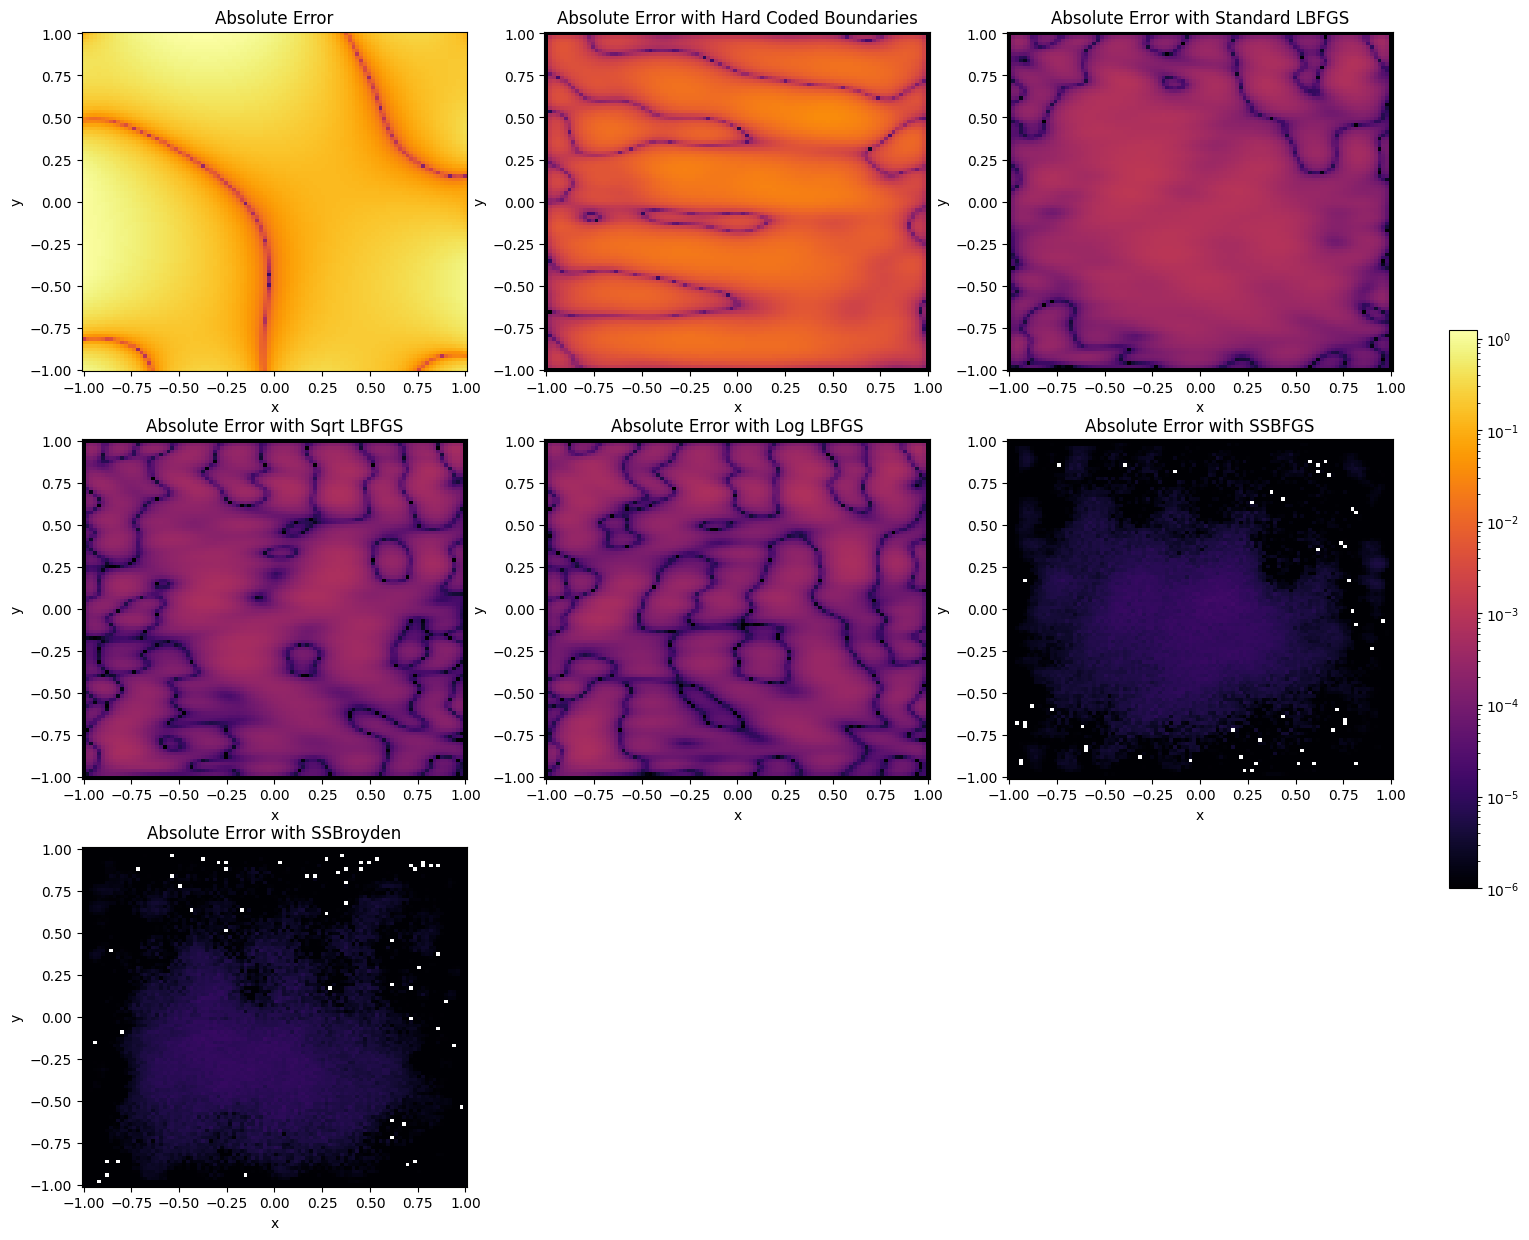

In [38]:
err_adam = torch.abs(u_pred - u_exact_vis)
err_hc = torch.abs(u_pred_hc - u_exact_vis)
err_std  = torch.abs(u_pred_std - u_exact_vis)
err_sqrt = torch.abs(u_pred_sqrt - u_exact_vis)
err_log  = torch.abs(u_pred_log - u_exact_vis)
err_ssbfgs = torch.abs(u_pred_ssbfgs - u_exact_vis)
err_ssbroyden  = torch.abs(u_pred_ssbroyden - u_exact_vis)


all_errors = [err_adam, err_hc, err_std, err_sqrt, err_log, err_ssbfgs, err_ssbroyden]
vmin_log = 1e-6
vmax = max(e.max() for e in all_errors)

fig = plt.figure(figsize=(18,15))

plt.subplot(3,3,1)
im = plt.pcolormesh(X, Y, err_adam, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,2)
plt.pcolormesh(X, Y, err_hc, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Hard Coded Boundaries')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,3)
plt.pcolormesh(X, Y, err_std, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Standard LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,4)
plt.pcolormesh(X, Y, err_sqrt, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Sqrt LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,5)
plt.pcolormesh(X, Y, err_log, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with Log LBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,6)
plt.pcolormesh(X, Y, err_ssbfgs, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with SSBFGS')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(3,3,7)
plt.pcolormesh(X, Y, err_ssbroyden, shading='auto', cmap='inferno', norm=colors.LogNorm(vmin=vmin_log, vmax=vmax))
plt.title('Absolute Error with SSBroyden')
plt.xlabel('x')
plt.ylabel('y')

fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

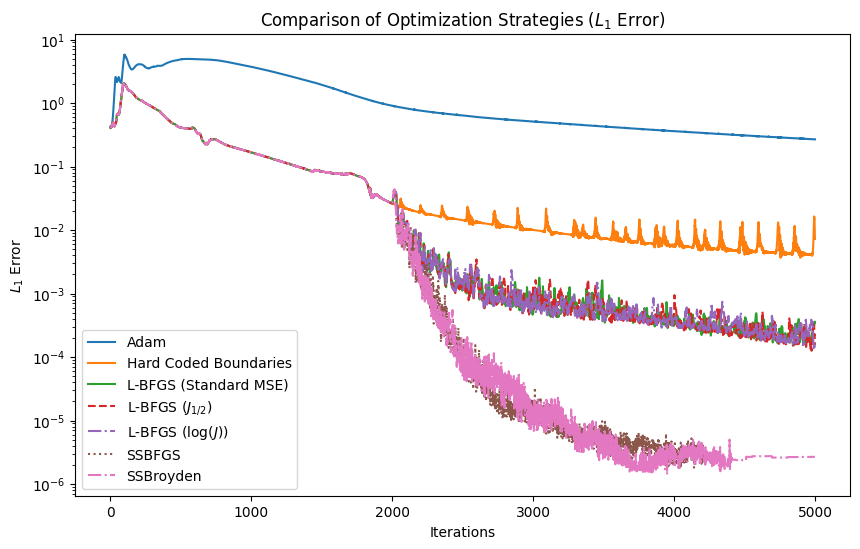

In [39]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l1_error["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(l1_error["HC Boundaries"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(l1_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l1_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l1_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l1_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l1_error["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'$L_1$ Error')
plt.title(r'Comparison of Optimization Strategies ($L_1$ Error)')
plt.legend()
plt.show()

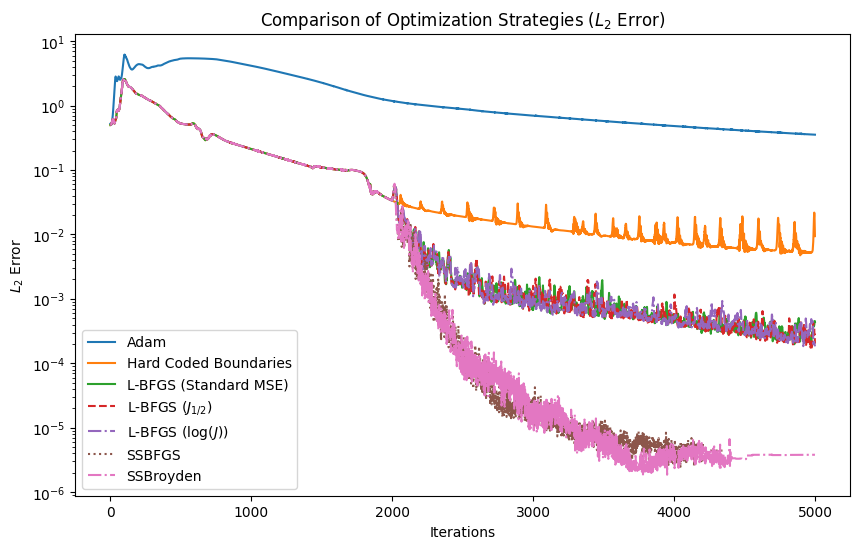

In [40]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l2_error["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(l2_error["HC Boundaries"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(l2_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l2_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l2_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l2_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l2_error["ssbroyden"], label='SSBroyden', linestyle='-.')

#plt.yscale('log') # Crucial to see the difference
plt.xlabel('Iterations')
plt.ylabel(r'$L_2$ Error')
plt.title(r'Comparison of Optimization Strategies ($L_2$ Error)')
plt.legend()
plt.show()

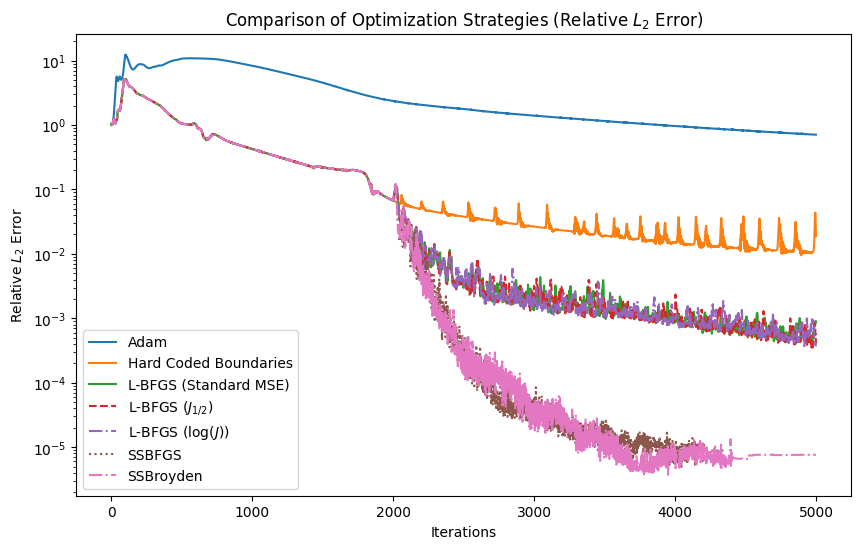

In [41]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l2_relative_error["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(l2_relative_error["HC Boundaries"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(l2_relative_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l2_relative_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l2_relative_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l2_relative_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l2_relative_error["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'Relative $L_2$ Error')
plt.title(r'Comparison of Optimization Strategies (Relative $L_2$ Error)')
plt.legend()
plt.show()

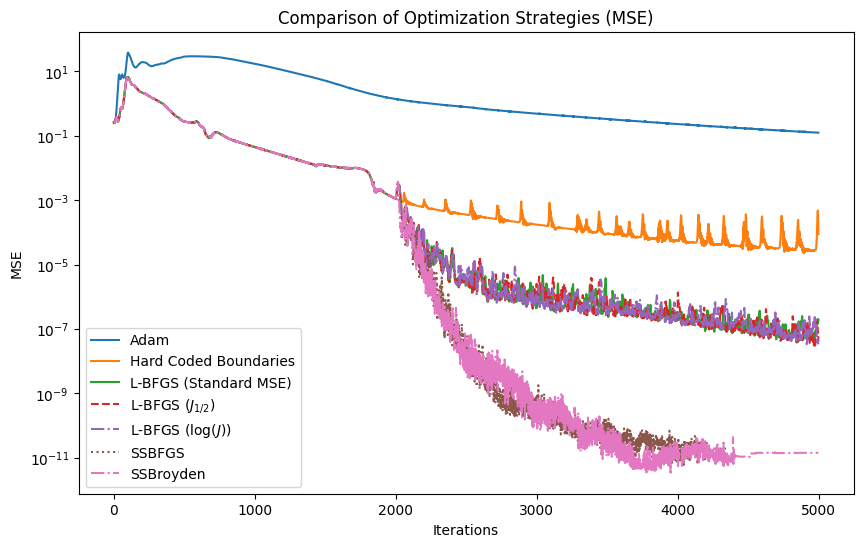

In [42]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(mse["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(mse["HC Boundaries"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(mse["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(mse["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(mse["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(mse["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(mse["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.title('Comparison of Optimization Strategies (MSE)')
plt.legend()
plt.show()

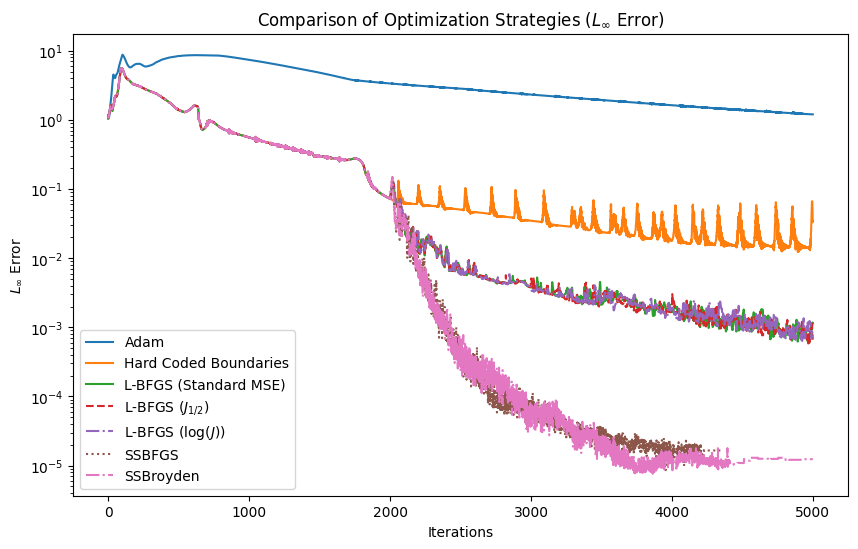

In [43]:
# --- PLOTTING ---
plt.figure(figsize=(10, 6))

plt.semilogy(l_inf_error["Standard"], label='Adam') # Exp 1: More Adam
plt.semilogy(l_inf_error["HC Boundaries"], label='Hard Coded Boundaries') # Exp 1: More Adam
plt.semilogy(l_inf_error["std"], label='L-BFGS (Standard MSE)') # Exp 2: Standard LBFGS
plt.semilogy(l_inf_error["sqrt"], label=r'L-BFGS ($J_{1/2}$)', linestyle='--')
plt.semilogy(l_inf_error["log"], label=r'L-BFGS ($\log(J)$)', linestyle='-.')
plt.semilogy(l_inf_error["ssbfgs"], label='SSBFGS', linestyle=':')
plt.semilogy(l_inf_error["ssbroyden"], label='SSBroyden', linestyle='-.')

plt.xlabel('Iterations')
plt.ylabel(r'$L_{\infty}$ Error')
plt.title('Comparison of Optimization Strategies ($L_{\infty}$ Error)')
plt.legend()
plt.show()

In [44]:
mse_adam = torch.mean(err_adam ** 2)
mse_hc = torch.mean(err_hc ** 2)
mse_std = torch.mean(err_std ** 2)
mse_sqrt = torch.mean(err_sqrt ** 2)
mse_log = torch.mean(err_log ** 2)
mse_ssbfgs = torch.mean(err_ssbfgs ** 2)
mse_ssbroyden = torch.mean(err_ssbroyden ** 2)


print("MSE:")
print(f"Adam: {mse_adam:.6e}")
print(f"HC Boundaries: {mse_hc:.6e}")
print(f"LBFGS: {mse_std:.6e}")
print(f"LBFGS J_1/2: {mse_sqrt:.6e}")
print(f"LBFGS log(J): {mse_log:.6e}")
print(f"SSBFGS: {mse_ssbfgs:.6e}")
print(f"SSBroyden: {mse_ssbroyden:.6e}")

MSE:
Adam: 1.310969e-01
HC Boundaries: 8.744870e-05
LBFGS: 1.939796e-07
LBFGS J_1/2: 4.110720e-08
LBFGS log(J): 3.434287e-08
SSBFGS: 1.966993e-11
SSBroyden: 1.446656e-11
